# CA1 – Numeric Variables
**Moustafa Almohamed – X00228076**

## 1. Setup and Data Loading

In [3]:
# libraries for tables and charts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset (columns are separated by ";")
df = pd.read_csv("data/bank-additional-full.csv", sep=";")
print(df.shape)  # (rows, columns)
df.head()        # first 5 rows

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Exploratory Data Analysis (Numeric Variables)
These are the 9 numeric input variables analysed in this section.

In [4]:
# list of the 9 numeric input columns
num_cols = ["age", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx",
            "euribor3m", "nr.employed"]
df[num_cols].head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0


### 2.1 Summary Statistics

In [5]:
# summary statistics for the numeric columns
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


All 9 numeric columns have 41,188 values, so there are no empty (NaN) values. Age ranges from 17 to 98, with an average of about 40, which looks realistic. For campaign, the median is 2 calls, but some clients were called up to 56 times, so there may be outliers. In pdays, the value 999 means the client was never contacted before, so it is not a real number of days and should be recoded. Most clients also have 0 previous contacts. Finally, the economic columns have very different scales, so the data will need to be scaled before using PCA.

### 2.2 Distributions (Histograms)
Histograms show how the values of each numeric variable are spread out.

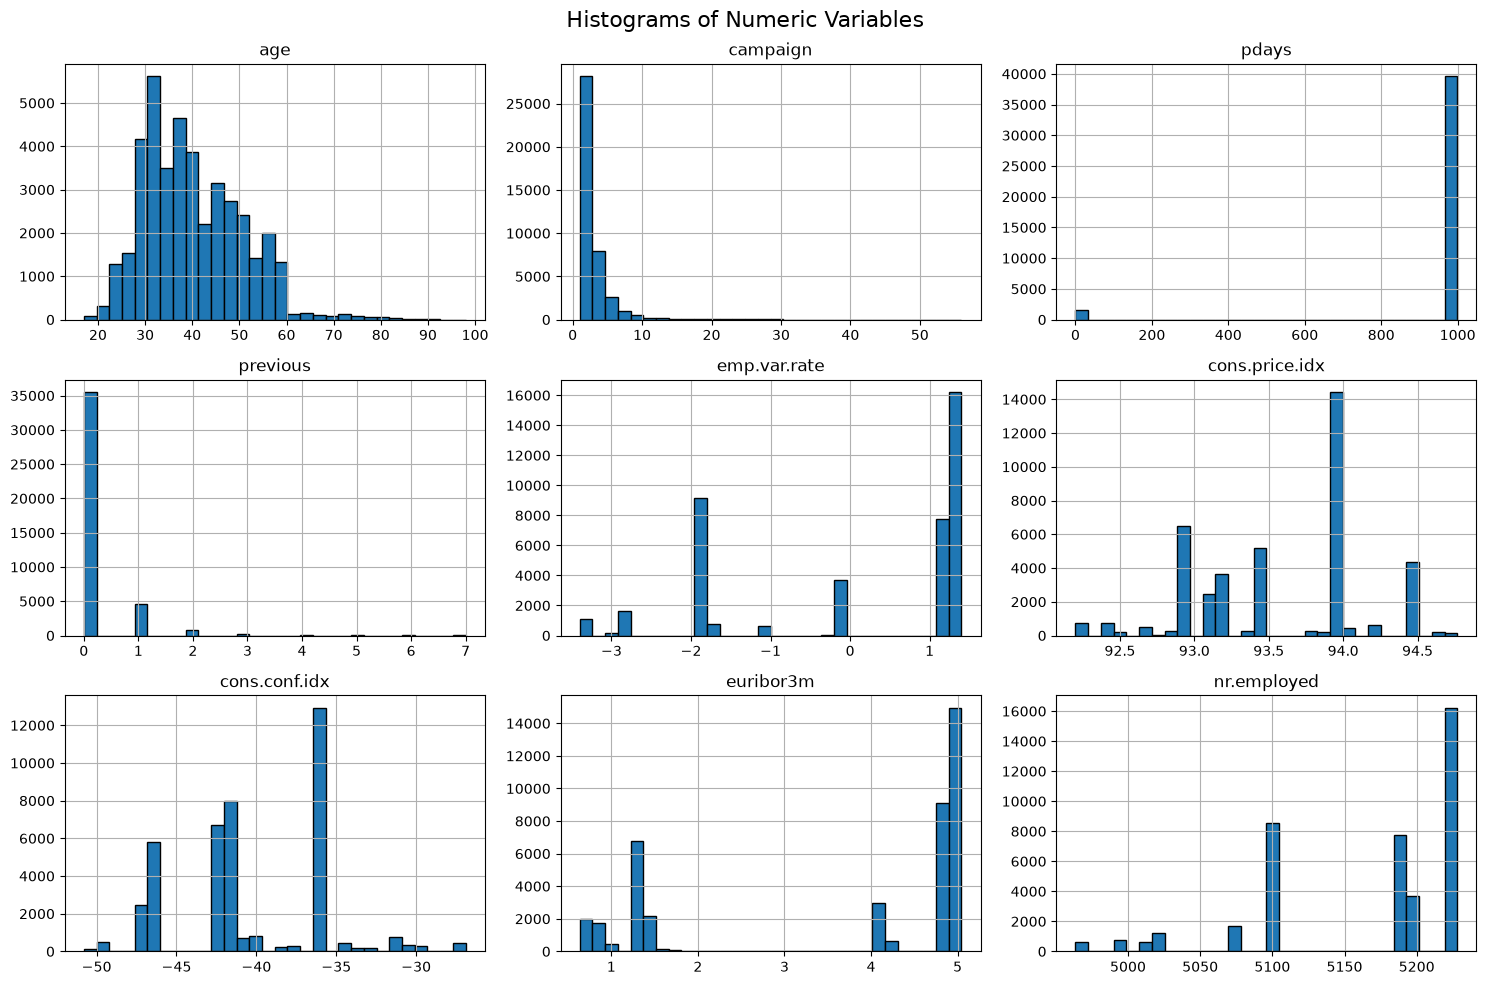

In [6]:
# histogram for each numeric column (3 rows x 3 columns of charts)
df[num_cols].hist(bins=30, figsize=(15, 10), edgecolor="black")
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

### 2.3 Outliers (Box Plots)
Box plots show the middle 50% of values (the box) and mark unusual values as dots.

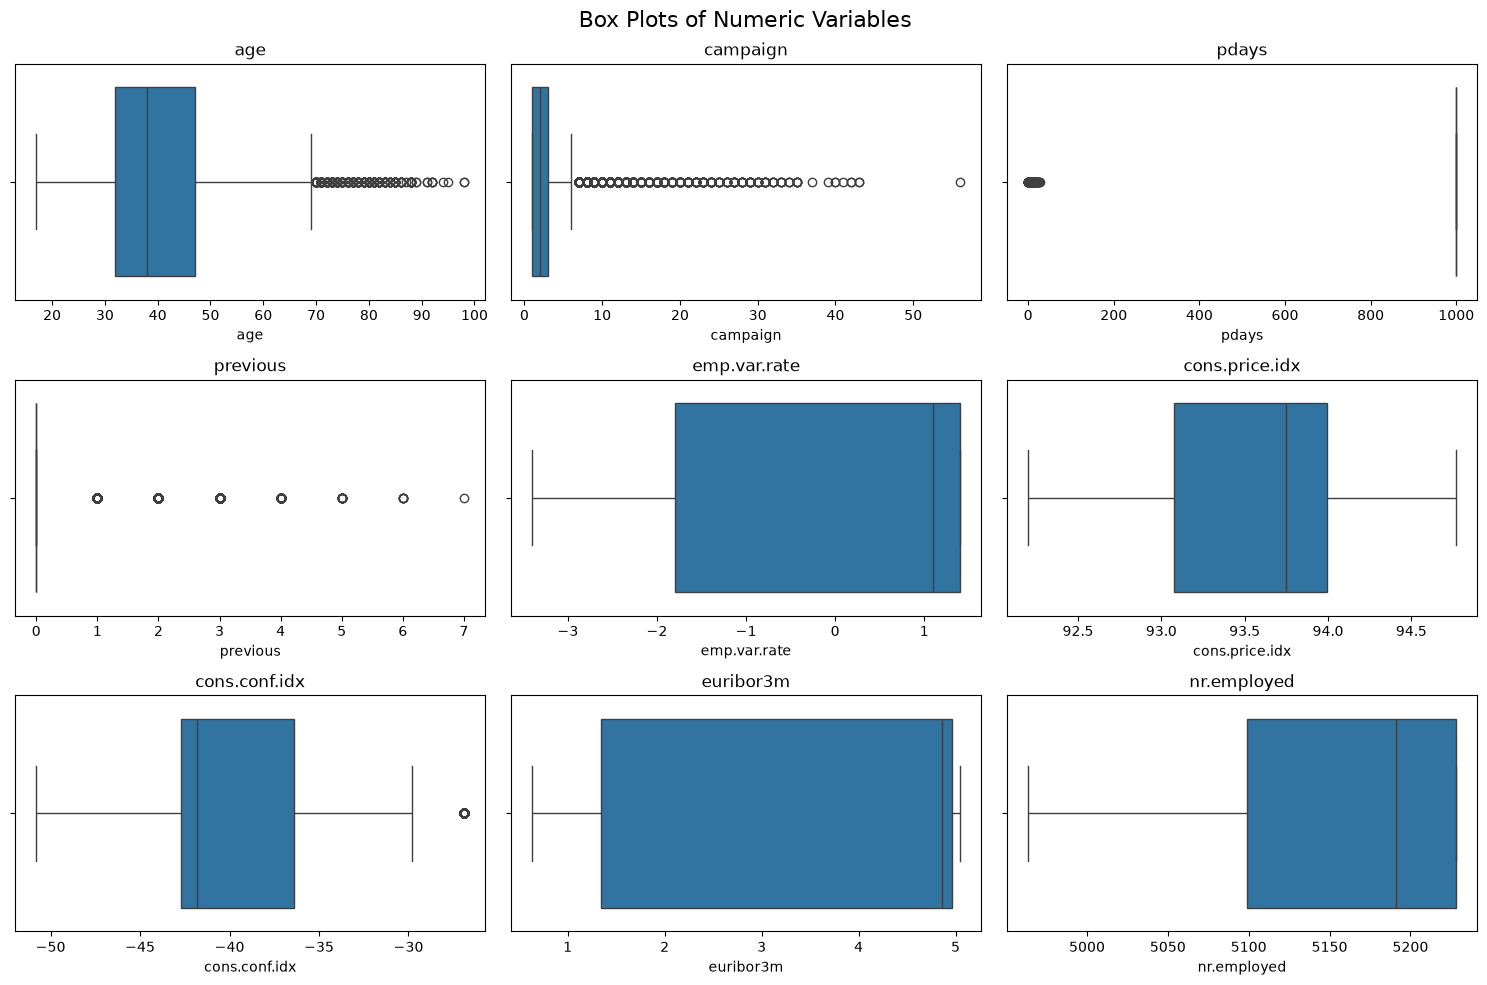

In [7]:
# one box plot per numeric column (separate charts because the scales are very different)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Box Plots of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretation:**
- `age` has upper outliers (about 70–98). These are realistic older clients, not data errors.
- `campaign` has many outliers (from about 7 up to 56 calls). This is the most important outlier problem and suggests capping or a log transformation.
- In `pdays` the box collapses at 999, so the real day values (0–27) are wrongly shown as outliers. This confirms that 999 is a code and must be recoded.
- In `previous` every value above 0 is flagged, simply because most clients have 0. These are valid values, not errors.
- `cons.conf.idx` has one outlier (about −27), which is a real monthly economic value.
- Not every box-plot outlier is an error; each one must be judged in context before deciding how to treat it.

### 2.4 Correlation Between Numeric Variables
The heatmap shows how strongly each pair of numeric variables moves together (from -1 to +1).

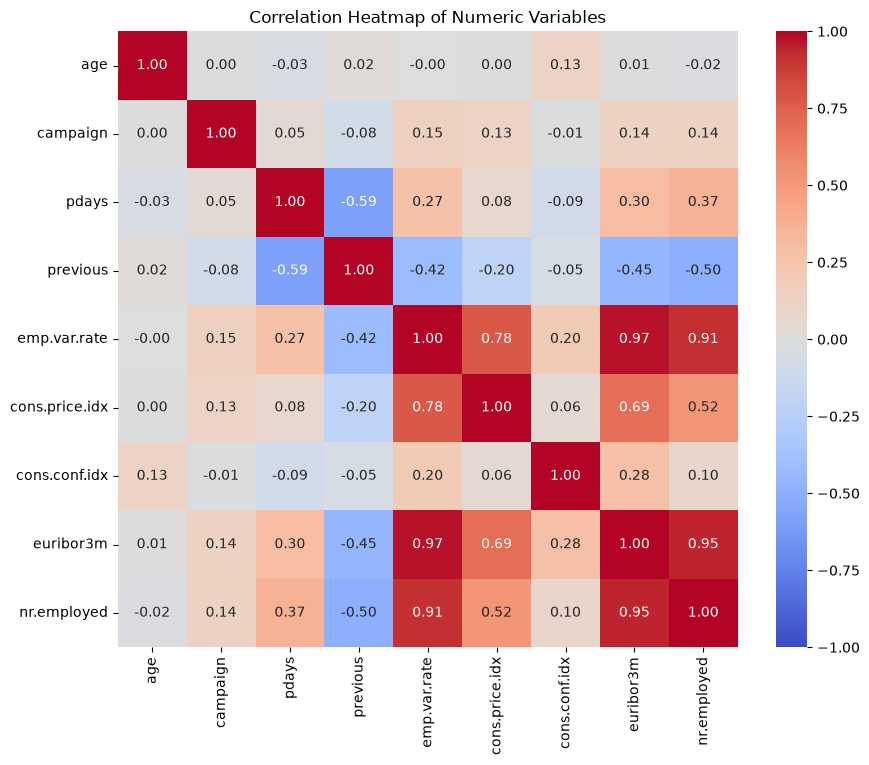

In [8]:
# correlation between every pair of numeric columns
corr = df[num_cols].corr()

# draw it as a coloured grid with the numbers shown
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

### 2.5 Scatter Plot
Checking visually how the two most correlated economic variables move together.

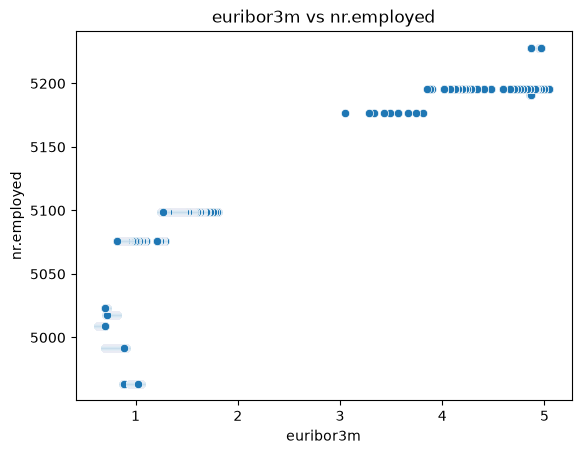

In [15]:
# scatter plot of the two most correlated economic variables
sns.scatterplot(x="euribor3m", y="nr.employed", data=df)
plt.title("euribor3m vs nr.employed")
plt.show()

**Interpretation:** The scatter plot confirms the strong positive relationship between `euribor3m` and `nr.employed` (r = 0.95): higher interest rates appear together with higher employment. The points form horizontal bands because `nr.employed` takes only 11 distinct values, recorded per time period rather than per client, so many points overlap. This visual redundancy supports checking these variables with VIF and combining them with PCA later.

## 3. Data Quality and Cleaning
### 3.1 Duplicate Rows
Checking whether any rows are exact copies of another row.

In [9]:
# count rows that are exact copies of an earlier row
print("Duplicate rows:", df.duplicated().sum())

# show the duplicated rows next to their copies
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Duplicate rows: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [10]:
# remove exact duplicate rows (keep the first copy)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 41176


**Interpretation:** 12 rows (0.03%) were exact duplicates across all 21 columns, including call duration in seconds, so they are very likely repeated records rather than different clients. They were removed, leaving 41,176 rows.

### 3.2 Data Types
Checking that each numeric variable is stored as a number.

In [11]:
# data type and number of different values for each numeric column
pd.DataFrame({"dtype": df[num_cols].dtypes,
              "unique_values": df[num_cols].nunique()})

,dtype,unique_values
age,int64,78
campaign,int64,42
pdays,int64,27
previous,int64,8
emp.var.rate,float64,10
cons.price.idx,float64,26
cons.conf.idx,float64,26
euribor3m,float64,316
nr.employed,float64,11


**Interpretation:** All numeric variables are stored with correct types: counts and ages as integers (`int64`) and economic indicators as decimals (`float64`), so no type conversion is needed. The economic indicators have very few distinct values (10–26, except `euribor3m` with 316) because they are recorded per time period rather than per client. `pdays` has 27 distinct values, one of which is the 999 code.

### 3.3 Outliers (IQR Method)
Counting values outside 1.5 × IQR to decide whether they are errors or valid extreme values.

In [12]:
# IQR rule: values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are outliers
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# count outliers per column
n_out = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
pd.DataFrame({"lower_limit": lower, "upper_limit": upper,
              "outliers": n_out, "percent": (n_out / len(df) * 100).round(2)})

,lower_limit,upper_limit,outliers,percent
age,9.5000,69.5000,468,1.14
campaign,-2.0000,6.0000,2406,5.84
pdays,999.0000,999.0000,1515,3.68
previous,0.0000,0.0000,5625,13.66
emp.var.rate,-6.6000,6.2000,0,0.00
cons.price.idx,91.6965,95.3725,0,0.00
cons.conf.idx,-52.1500,-26.9500,446,1.08
euribor3m,-4.0815,10.3865,0,0.00
nr.employed,4905.6000,5421.6000,0,0.00


### 3.4 Recoding `pdays` (999 code)
`pdays = 999` means the client was never contacted before. It is a code, not a real number of days, so it is replaced with a yes/no indicator.

In [13]:
# new yes/no column: 1 = contacted in a previous campaign, 0 = never (999)
df["prev_contacted"] = (df["pdays"] != 999).astype(int)
print(df["prev_contacted"].value_counts())

# remove the original pdays column and update the numeric list
df = df.drop(columns="pdays")
num_cols.remove("pdays")
print("Numeric columns now:", num_cols)

prev_contacted
0    39661
1     1515
Name: count, dtype: int64
Numeric columns now: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


**Interpretation:** 999 was replaced by a binary indicator `prev_contacted` (1 = contacted in a previous campaign, 0 = never). Only 1,515 clients (3.7%) had been contacted before, while 39,661 had the 999 code. The original `pdays` column was removed, as its exact day values applied to very few clients and the 999 code would mislead later steps such as scaling and PCA. The number of previous contacts is still kept in `previous`. This is a fixed rule (not learned from the data), so it does not cause data leakage.

## 4. Train/Test Split
The data is split into 80% training and 20% test before any further preparation, so the test data stays unseen.

In [16]:
from sklearn.model_selection import train_test_split

# X = the information about clients, y = the answer (yes/no)
X = df.drop(columns="y")
y = df["y"]

# cut into 80% train and 20% test, same yes/no mix in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (32940, 20)  Test: (8236, 20)


**Interpretation:** The data was split into a training set (32,940 rows, 80%) and a test set (8,236 rows, 20%). The split is stratified on `y`, so both sets keep the same proportion of "yes" clients (about 11%). `random_state=42` makes the split reproducible. From now on, all preparation steps (scaling, transformations, PCA) are fitted on the training set only, and the test set is kept untouched.

## 5. Transformations
### 5.1 Log Transformation of `campaign`
`campaign` is strongly right-skewed (most clients 1–3 calls, maximum 56). A log(1 + x) transformation reduces the effect of extreme values while keeping their order.

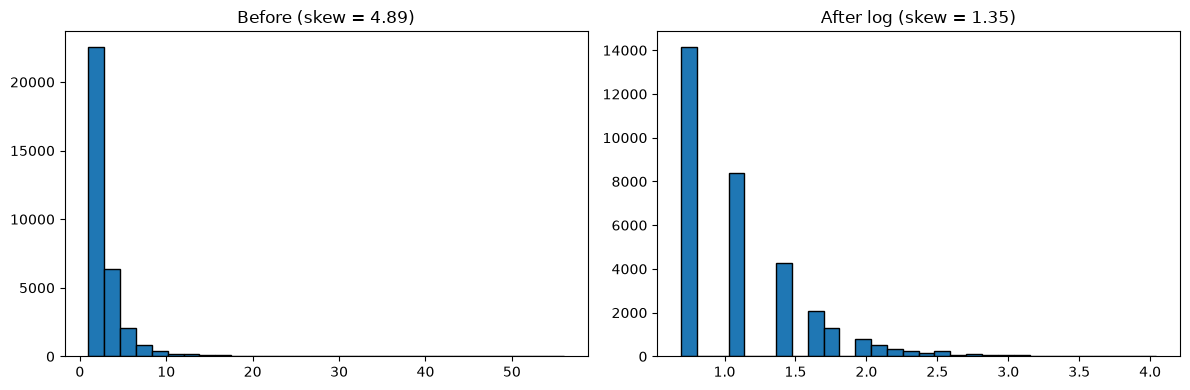

In [17]:
import numpy as np

# compare the shape before and after the log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train["campaign"], bins=30, edgecolor="black")
axes[0].set_title(f"Before (skew = {X_train['campaign'].skew():.2f})")

# log(1 + x) is a fixed formula, so it is applied the same way to both sets
X_train["campaign"] = np.log1p(X_train["campaign"])
X_test["campaign"] = np.log1p(X_test["campaign"])

axes[1].hist(X_train["campaign"], bins=30, edgecolor="black")
axes[1].set_title(f"After log (skew = {X_train['campaign'].skew():.2f})")
plt.tight_layout()
plt.show()

**Interpretation:** The log(1 + x) transformation reduced the skewness of `campaign` from 4.89 to 1.35, and the maximum value fell from 56 calls to about 4.0 on the log scale. The extreme values are kept (not removed) but have much less influence. Because the log is a fixed formula that does not learn from the data, it was applied to both the training and test sets without causing leakage.


### 5.2 Scaling Numeric Variables
The numeric variables are on very different scales (e.g. `nr.employed` ≈ 5,000 vs `euribor3m` ≈ 1–5). They are standardised to mean 0 and standard deviation 1. The scaler is fitted on the training set only and then applied to the test set, to avoid data leakage.

In [18]:
from sklearn.preprocessing import StandardScaler

# learn mean and std from the TRAINING set only, then apply to both sets
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]),
                           columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]),
                          columns=num_cols, index=X_test.index)

# check: training means should be 0 and std 1
X_train_num.describe().T[["mean", "std"]].round(2)

,mean,std
age,-0.0,1.0
campaign,0.0,1.0
previous,0.0,1.0
emp.var.rate,-0.0,1.0
cons.price.idx,0.0,1.0
cons.conf.idx,0.0,1.0
euribor3m,-0.0,1.0
nr.employed,0.0,1.0


**Interpretation:** After standardisation, all eight numeric variables in the training set have a mean of 0 and a standard deviation of 1, so no variable dominates because of its original units (for example `nr.employed`, which was around 5,000). The scaler learned its parameters from the training set only, and the test set was transformed with those same parameters, so no test information leaked into the preparation. The binary `prev_contacted` indicator was not scaled.

## 6. Correlation, Multicollinearity and PCA
### 6.1 Correlation Matrix (Training Data)
The correlation matrix is recomputed on the training set only, to identify redundant numeric variables before VIF and PCA.

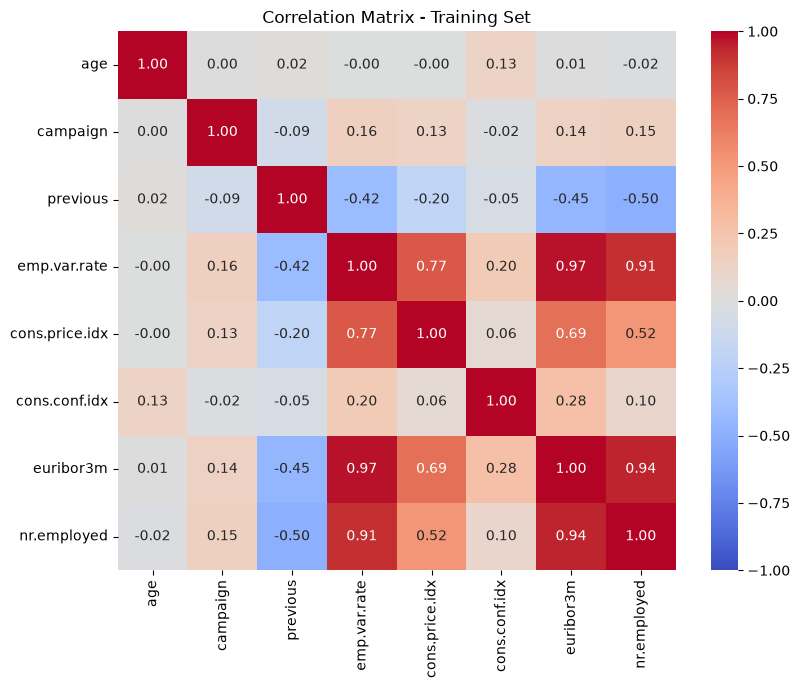

emp.var.rate  euribor3m      0.97
              nr.employed    0.91
euribor3m     nr.employed    0.94
dtype: float64


In [19]:
# correlation of the scaled numeric variables (training set only)
corr_train = X_train_num.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_train, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Training Set")
plt.show()

# list the strongly correlated pairs (|r| > 0.8)
pairs = corr_train.where(np.triu(np.ones(corr_train.shape, dtype=bool), k=1)).stack()
print(pairs[pairs.abs() > 0.8].round(2))

**Interpretation:** On the training set, three economic indicators remain very strongly correlated: `emp.var.rate`–`euribor3m` (0.97), `euribor3m`–`nr.employed` (0.94) and `emp.var.rate`–`nr.employed` (0.91). `cons.price.idx` is also strongly related to `emp.var.rate` (0.77). These values are almost identical to the EDA results on the full data, confirming that the training set is representative. `age`, `campaign` and `cons.conf.idx` show weak correlations with all other variables. The strong redundancy among the economic indicators will be measured with VIF next and addressed with PCA.

### 6.2 Multicollinearity (VIF)
The Variance Inflation Factor (VIF) measures how much each numeric variable can be predicted from all the others. VIF above 10 indicates severe multicollinearity.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

# VIF for each numeric variable (training set only)
X_vif = add_constant(X_train_num)
vif = pd.DataFrame({
    "variable": num_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(num_cols))]
}).sort_values("VIF", ascending=False).round(2)
vif

,variable,VIF
6,euribor3m,64.57
3,emp.var.rate,33.28
7,nr.employed,31.56
4,cons.price.idx,6.31
5,cons.conf.idx,2.61
2,previous,1.35
1,campaign,1.04
0,age,1.02


**Interpretation:** Three economic indicators show severe multicollinearity: `euribor3m` (VIF 64.6), `emp.var.rate` (33.3) and `nr.employed` (31.6), far above the threshold of 10. These variables largely describe the same economic conditions. `cons.price.idx` shows moderate overlap (6.3), while `cons.conf.idx`, `previous`, `campaign` and `age` have low VIF (below 3). Instead of deleting variables, PCA is applied next to combine the repeated information.

### 6.3 Principal Component Analysis (PCA)
PCA is fitted on the scaled numeric training data to combine correlated variables into uncorrelated components. The explained variance shows how much information each component keeps.

  component  explained_%  cumulative_%
0       PC1         46.7          46.7
1       PC2         14.2          60.9
2       PC3         12.2          73.1
3       PC4         10.6          83.7
4       PC5         10.6          94.3
5       PC6          5.3          99.6
6       PC7          0.3          99.9
7       PC8          0.1         100.0


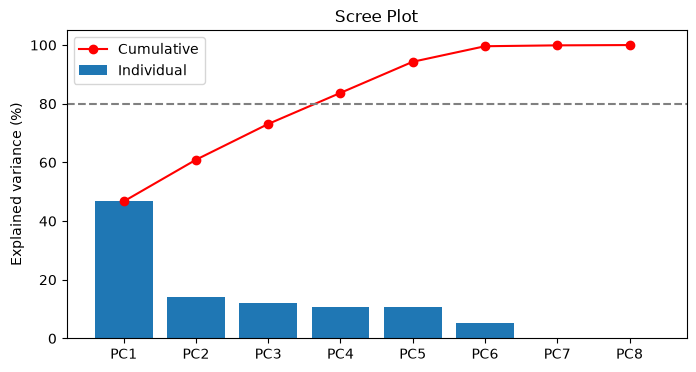

In [21]:
from sklearn.decomposition import PCA

# fit PCA on the scaled numeric training data
pca = PCA()
pca.fit(X_train_num)

# how much information (variance) each component keeps
expl = pca.explained_variance_ratio_
pca_table = pd.DataFrame({"component": [f"PC{i+1}" for i in range(len(expl))],
                          "explained_%": (expl * 100).round(1),
                          "cumulative_%": (expl.cumsum() * 100).round(1)})
print(pca_table)

# scree plot: bars = each component, line = running total
plt.figure(figsize=(8, 4))
plt.bar(pca_table["component"], pca_table["explained_%"], label="Individual")
plt.plot(pca_table["component"], pca_table["cumulative_%"], marker="o", color="red", label="Cumulative")
plt.axhline(80, linestyle="--", color="grey")
plt.ylabel("Explained variance (%)")
plt.title("Scree Plot")
plt.legend()
plt.show()

**Interpretation:** PC1 alone explains 46.7% of the variance, mainly reflecting the strongly correlated economic indicators. The first four components together explain 83.7%, passing the common 80% threshold, and five components explain 94.3%. PC7 and PC8 explain only 0.4% combined, which confirms the multicollinearity found with VIF: the eight numeric variables contain about six dimensions of genuinely different information.

### 6.4 Choosing the Number of Components
Four components are kept: this is the smallest number that explains more than 80% of the variance (83.7%), reducing the numeric variables from 8 to 4.

In [22]:
# keep 4 components, learned from the TRAINING set only
pca4 = PCA(n_components=4)
X_train_pca = pd.DataFrame(pca4.fit_transform(X_train_num),
                           columns=["PC1", "PC2", "PC3", "PC4"], index=X_train.index)
X_test_pca = pd.DataFrame(pca4.transform(X_test_num),
                          columns=["PC1", "PC2", "PC3", "PC4"], index=X_test.index)

print("Train:", X_train_pca.shape, " Test:", X_test_pca.shape)
print("Variance kept:", round(pca4.explained_variance_ratio_.sum() * 100, 1), "%")

Train: (32940, 4)  Test: (8236, 4)
Variance kept: 83.7 %


**Interpretation:** The eight scaled numeric variables were reduced to four principal components, which keep 83.7% of the variance. PCA was fitted on the training set only and the same transformation was applied to the test set, so no test information was used. This halves the number of numeric features while removing the multicollinearity, because principal components are uncorrelated with each other.

### 6.5 Interpreting the Components (Loadings)
Loadings show how strongly each original variable contributes to each component.

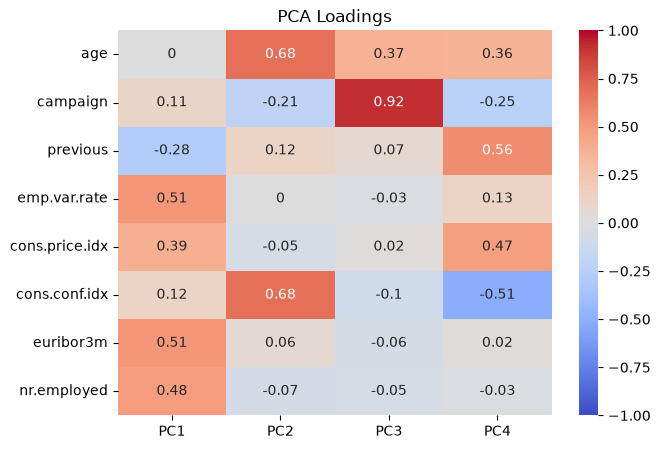

In [23]:
# loadings: contribution of each original variable to each component
loadings = pd.DataFrame(pca4.components_.T, index=num_cols,
                        columns=["PC1", "PC2", "PC3", "PC4"]).round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(loadings, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("PCA Loadings")
plt.show()

**Interpretation:**
- **PC1 (46.7%) – economic conditions:** high, similar loadings on `emp.var.rate` (0.51), `euribor3m` (0.51) and `nr.employed` (0.48), plus `cons.price.idx` (0.39). PC1 combines the redundant economic indicators into a single component.
- **PC2 (14.2%) – age and consumer confidence:** driven by `age` (0.68) and `cons.conf.idx` (0.68).
- **PC3 (12.2%) – campaign intensity:** almost entirely `campaign` (0.92), i.e. the number of calls in the current campaign.
- **PC4 (10.6%) – previous contact and price/confidence:** `previous` (0.56), `cons.price.idx` (0.47) and `cons.conf.idx` (−0.51).

PC1 and PC3 have a clear meaning, while PC2 and PC4 mix variables that are not naturally related, which makes them harder to interpret. This is a known limitation of PCA and will be weighed against feature selection, which keeps the original, interpretable variables.